In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
# Update to your local path
users = pd.read_csv("users_data.csv")
cards = pd.read_csv("cards_data.csv")
df = pd.read_csv('transactions_data.csv', parse_dates=['date'])
fraud_labels = pd.read_json("train_fraud_labels.json")


In [12]:
df.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


In [ ]:
fraud_labels = fraud_labels.reset_index()
fraud_labels.columns = ["transaction_id", "is_fraud"]
# merge transaction fraud booleon to main transaction dataframe
fraud_labels["transaction_id"] = fraud_labels["transaction_id"].astype(int)
df = df.merge(fraud_labels, left_on="id", right_on="transaction_id", how="inner")
df["is_fraud"] = df["is_fraud"].map({"Yes": 1, "No": 0})

# remove $
for col in ["amount", "per_capita_income", "yearly_income", "total_debt", "credit_limit"]:
    for src in [users, cards]:
        if col in src.columns and src[col].dtype == object:
            src[col] = src[col].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)

df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek

fraud_rate = df["is_fraud"].mean() * 100
print(f"Total txns: {len(df):,} | Fraud: {df['is_fraud'].sum():,} ({fraud_rate:.2f}%)")


print(f"Successfully merged data. Total rows: {len(df)}")


Total txns: 8,914,963 | Fraud: 13,332 (0.15%)
Successfully merged data. Total rows: 8914963


In [5]:
df.head()


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,transaction_id,is_fraud
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN,7475327,No
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN,7475328,No
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,7475329,No
3,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN,7475332,No
4,7475333,2010-01-01 00:07:00,1807,165,$4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,NaN,7475333,No


Text(0.5, 0, 'Entry Method (Swipe, Chip, Online, etc.)')

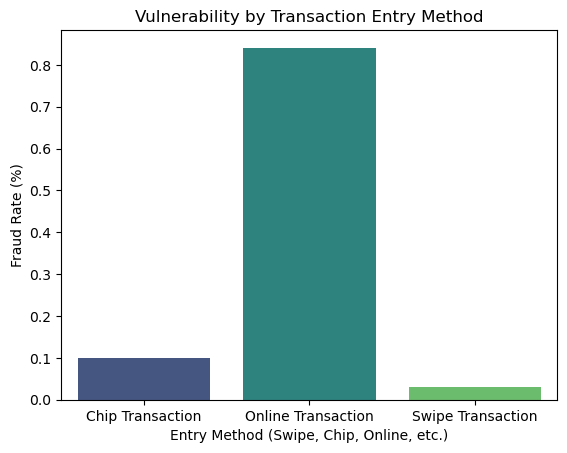

In [ ]:
# Calculate percentage of fraud for each chip method
fraud_rates = df.groupby('use_chip')['is_fraud'].mean() * 100
sns.barplot(x=fraud_rates.index, y=fraud_rates.values, hue=fraud_rates.index, palette="viridis", legend=False)
plt.ylabel('Fraud Rate (%)')
plt.title('Vulnerability by Transaction Entry Method')
plt.xlabel('Entry Method (Swipe, Chip, Online, etc.)')


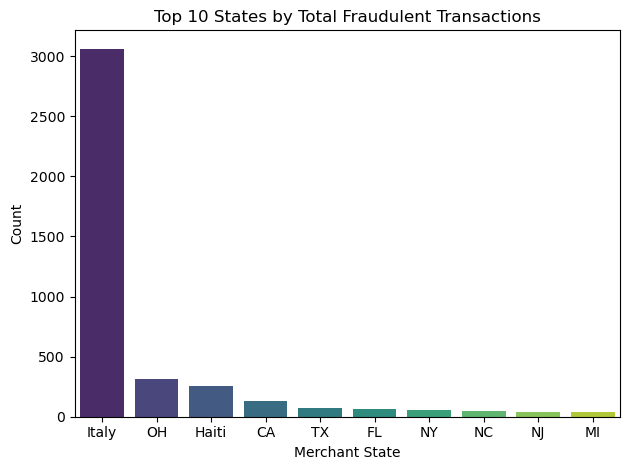

In [ ]:
# Get total fraud cases per state
state_fraud = df.groupby('merchant_state')['is_fraud'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=state_fraud.index, y=state_fraud.values, hue=state_fraud.index, palette="viridis", legend=False)
plt.title('Top 10 States by Total Fraudulent Transactions')
plt.xlabel('Merchant State')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

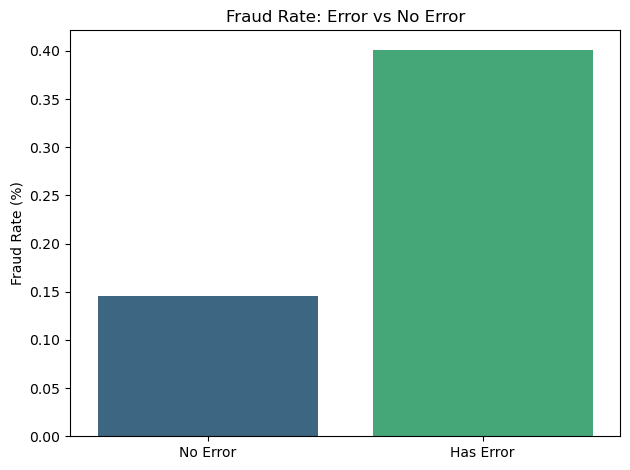

In [ ]:
# How oten do fraudulent transactions have errors occur
df["has_error"] = df["errors"].notna().astype(int)
err_rate = df.groupby("has_error")["is_fraud"].mean() * 100
labels = ["No Error", "Has Error"]
sns.barplot(x=labels, y=err_rate.values, hue=labels, palette="viridis", legend=False)
plt.title("Fraud Rate: Error vs No Error")
plt.xlabel("")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

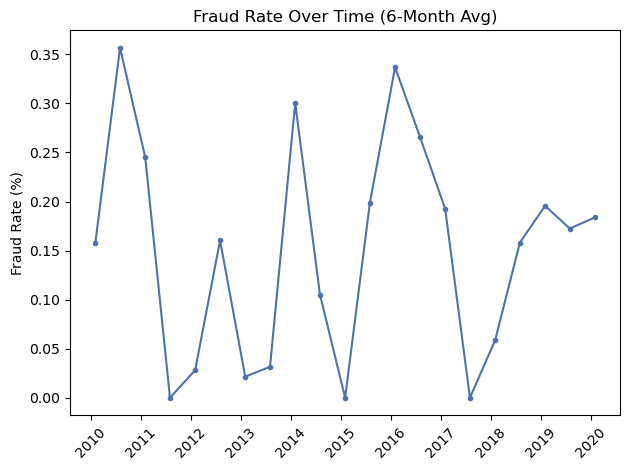

In [ ]:
monthly = df.set_index("date").resample("6ME")["is_fraud"].mean() * 100
plt.plot(monthly.index, monthly.values, marker="o", markersize=3)
plt.title("Fraud Rate Over Time (6-Month Avg)")
plt.xlabel("")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Model Performance Comparison

Comparison of three machine learning models for fraud detection.

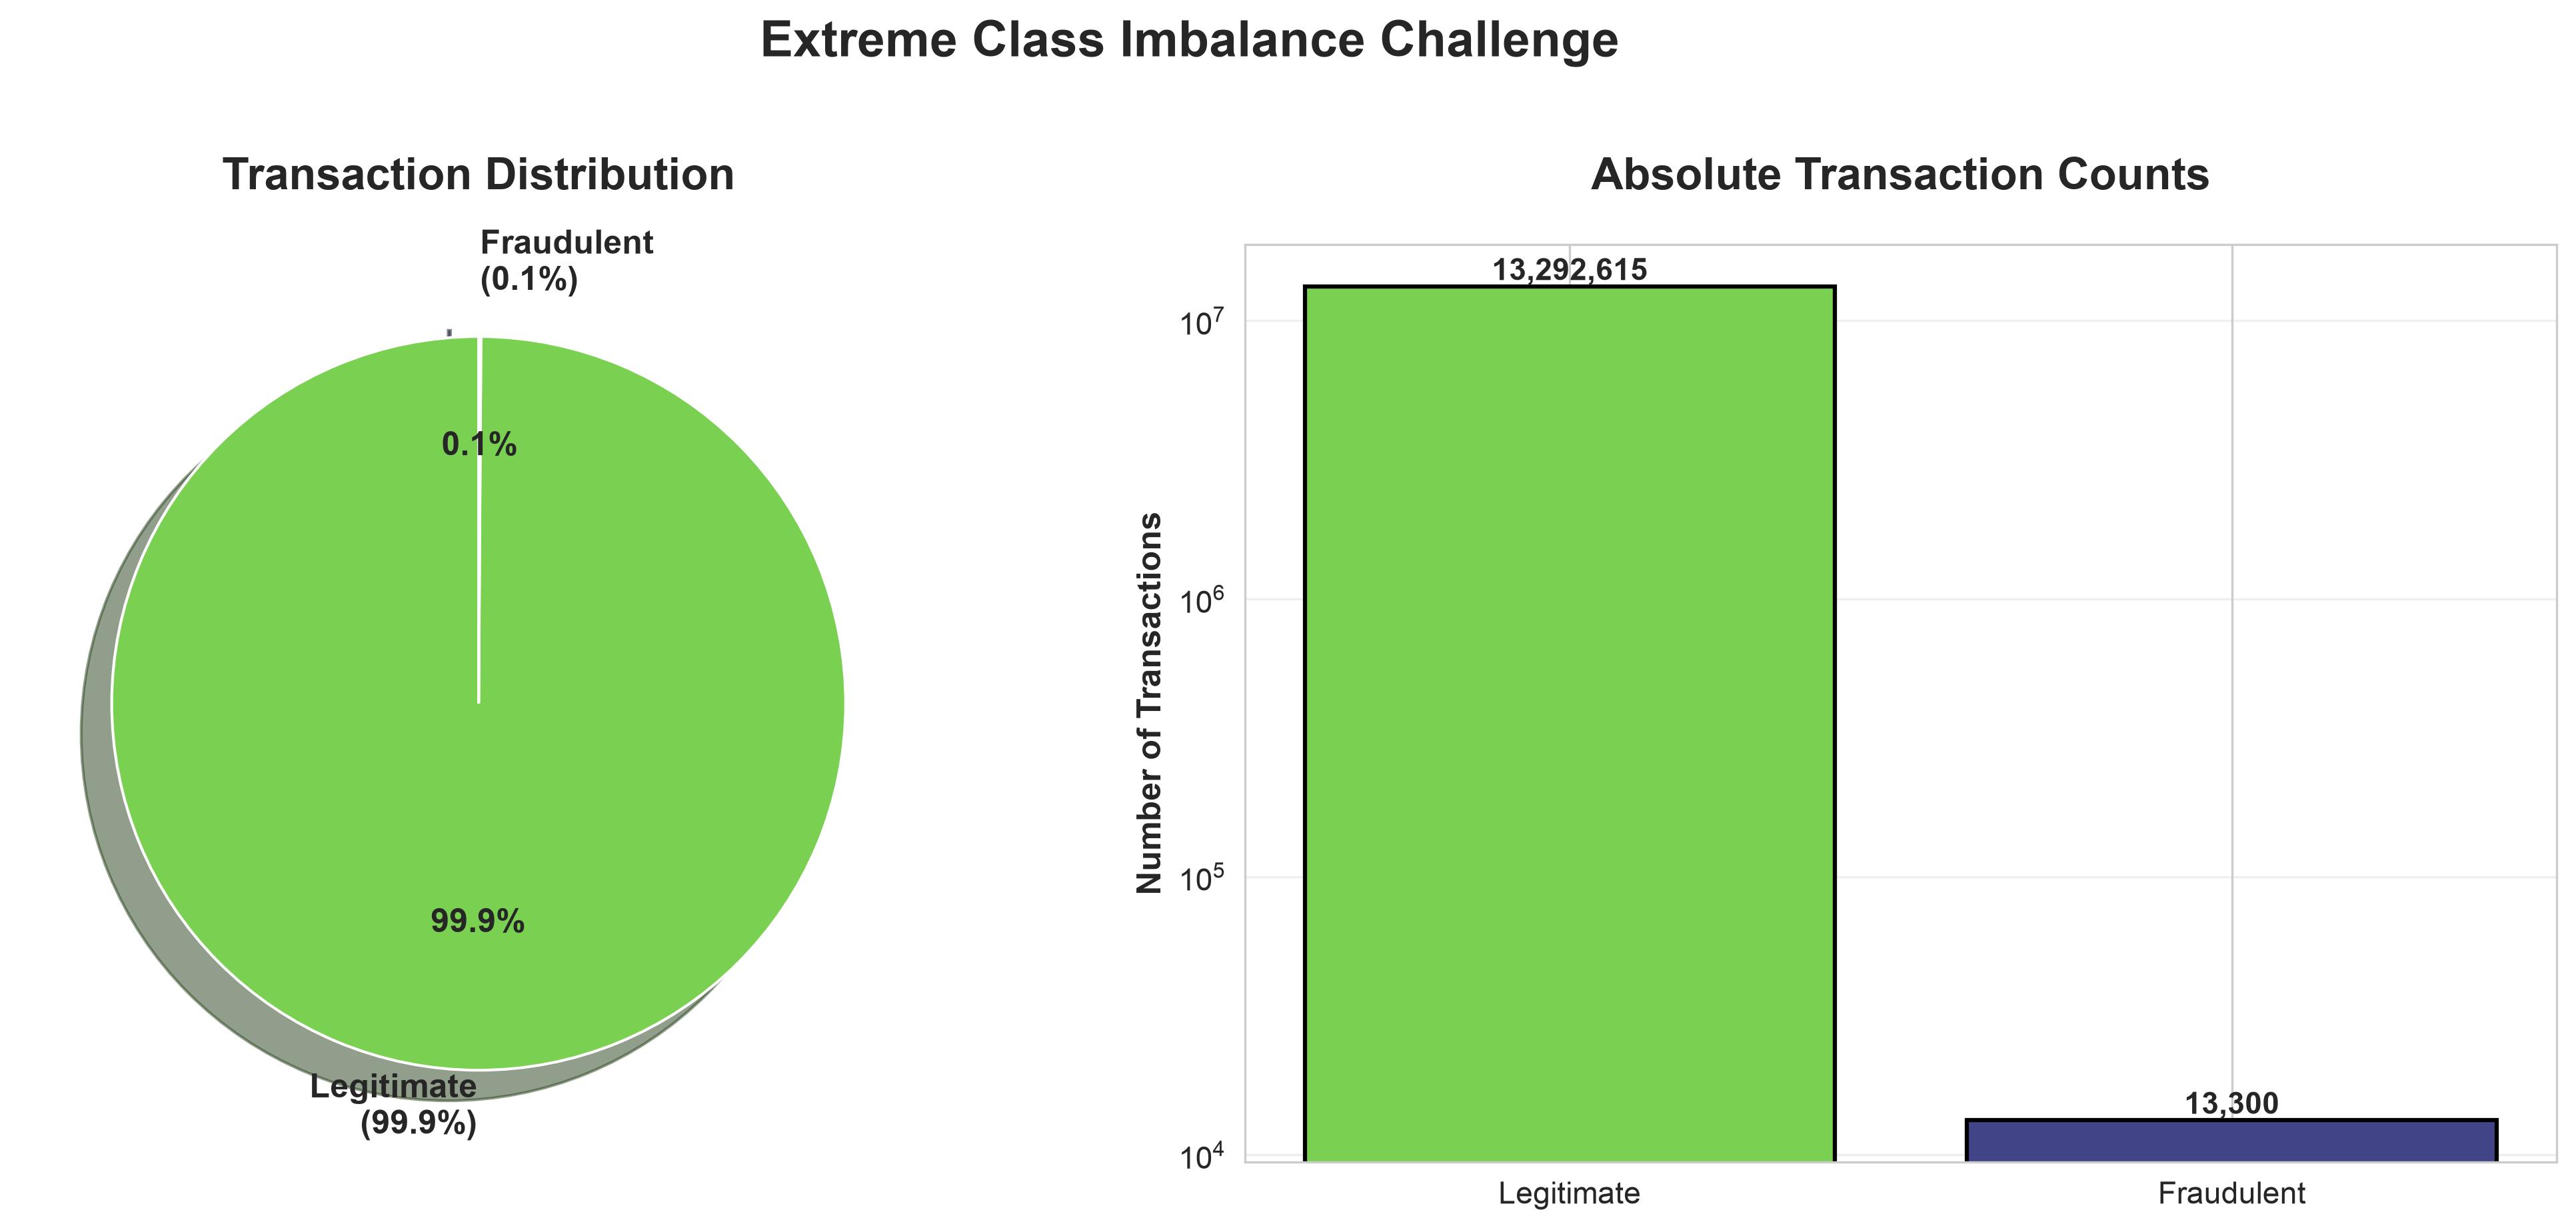

In [1]:
# Class Imbalance Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart - using viridis colors
viridis_colors = plt.cm.viridis([0.8, 0.2])
labels = ['Legitimate\n(99.9%)', 'Fraudulent\n(0.1%)']
sizes = [99.9, 0.1]
explode = (0, 0.1)

ax1.pie(sizes, explode=explode, labels=labels, colors=viridis_colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
ax1.set_title('Transaction Distribution', fontsize=16, fontweight='bold', pad=20)

# Bar chart
categories = ['Legitimate', 'Fraudulent']
counts = [13292615, 13300]
bars = ax2.bar(categories, counts, color=viridis_colors, edgecolor='black', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel('Number of Transactions', fontsize=12, fontweight='bold')
ax2.set_title('Absolute Transaction Counts', fontsize=16, fontweight='bold', pad=20)
ax2.set_yscale('log')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Extreme Class Imbalance Challenge', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/images/class_imbalance.png', bbox_inches='tight', dpi=300)
plt.show()

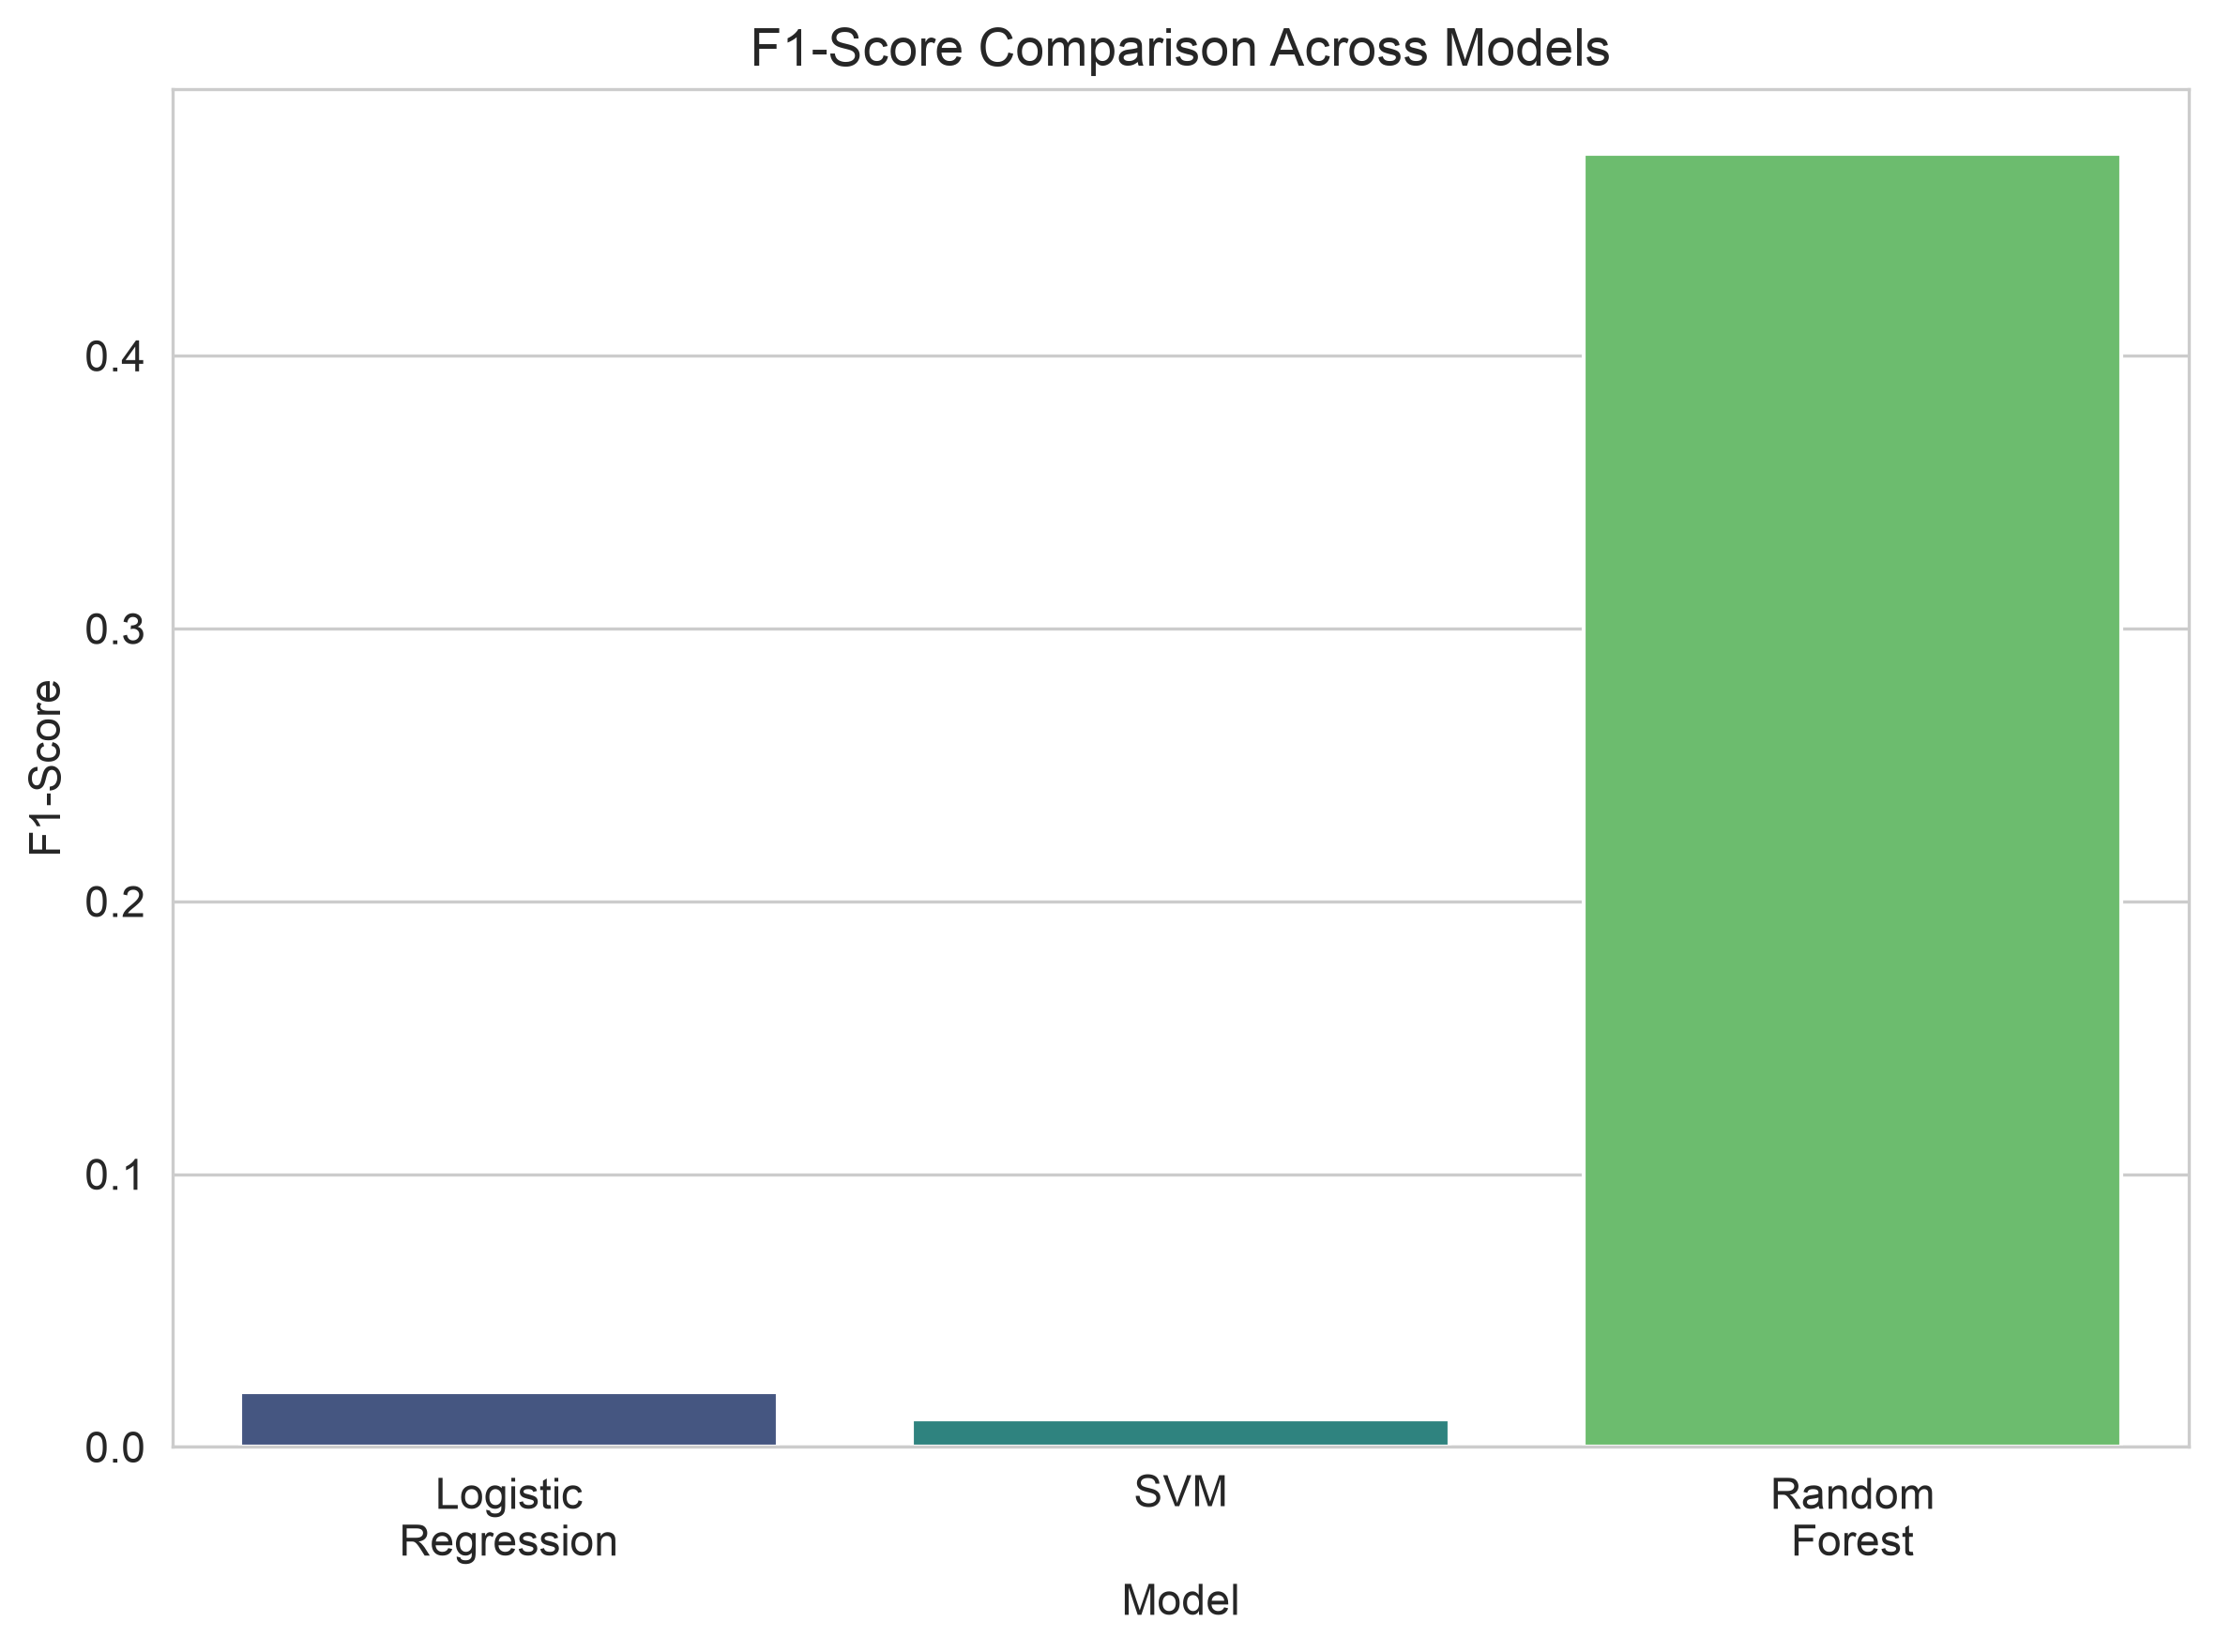

In [1]:
# F1-Score Comparison Across Models
models = ['Logistic\nRegression', 'SVM', 'Random\nForest']
f1_scores = [0.02, 0.01, 0.474]

sns.barplot(x=models, y=f1_scores, hue=models, palette="viridis", legend=False)
plt.ylabel('F1-Score')
plt.title('F1-Score Comparison Across Models')
plt.xlabel('Model')

plt.tight_layout()
plt.savefig('assets/images/model_comparison_f1.png', bbox_inches='tight', dpi=300)
plt.show()

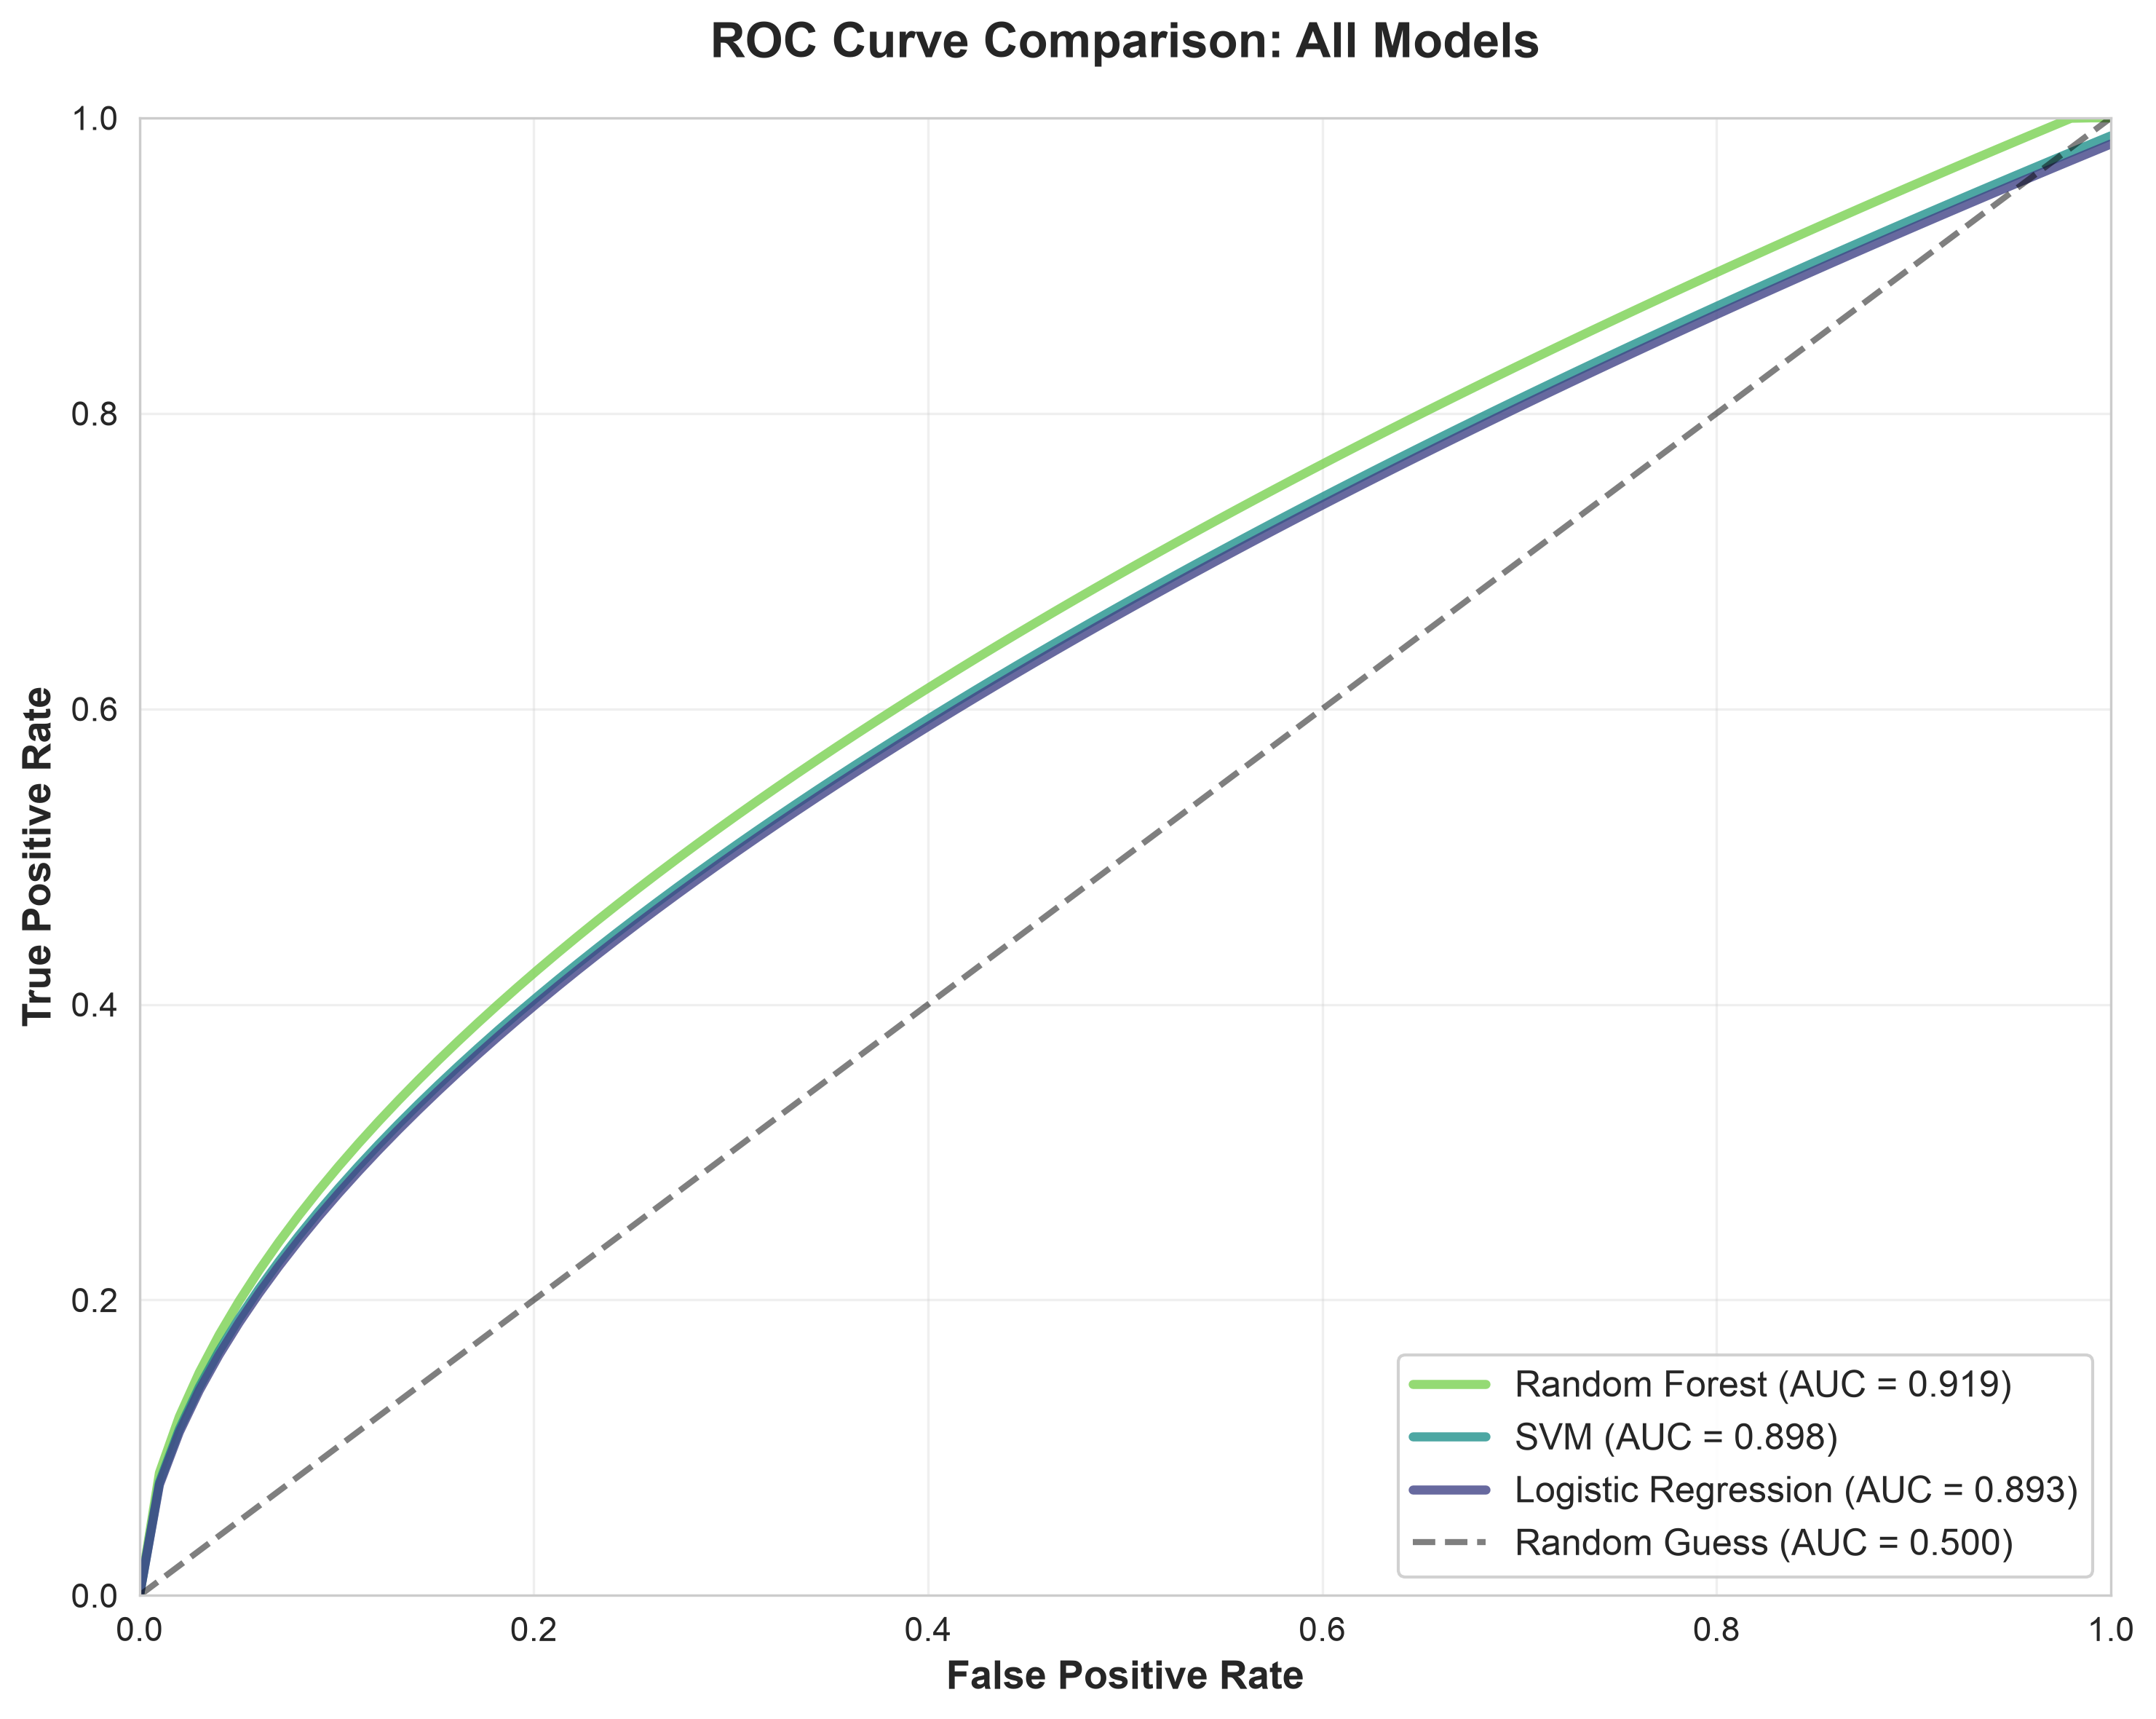

In [1]:
# ROC Curve Comparison
import numpy as np

# Use viridis colors for consistency
viridis_colors_3 = plt.cm.viridis([0.8, 0.5, 0.2])

models = {
    'Random Forest': {'auc': 0.919, 'color': viridis_colors_3[0]},
    'SVM': {'auc': 0.898, 'color': viridis_colors_3[1]},
    'Logistic Regression': {'auc': 0.893, 'color': viridis_colors_3[2]}
}

plt.figure(figsize=(10, 8))
for model_name, data in models.items():
    fpr = np.linspace(0, 1, 100)
    auc = data['auc']
    tpr = np.power(fpr, 1/(2*auc)) * auc * 1.1
    tpr = np.minimum(tpr, 1.0)
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})",
             color=data['color'], linewidth=3, alpha=0.8)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)', linewidth=2, alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curve Comparison: All Models', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=12, framealpha=0.9)
plt.grid(alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.savefig('assets/images/model_comparison_roc.png', bbox_inches='tight', dpi=300)
plt.show()

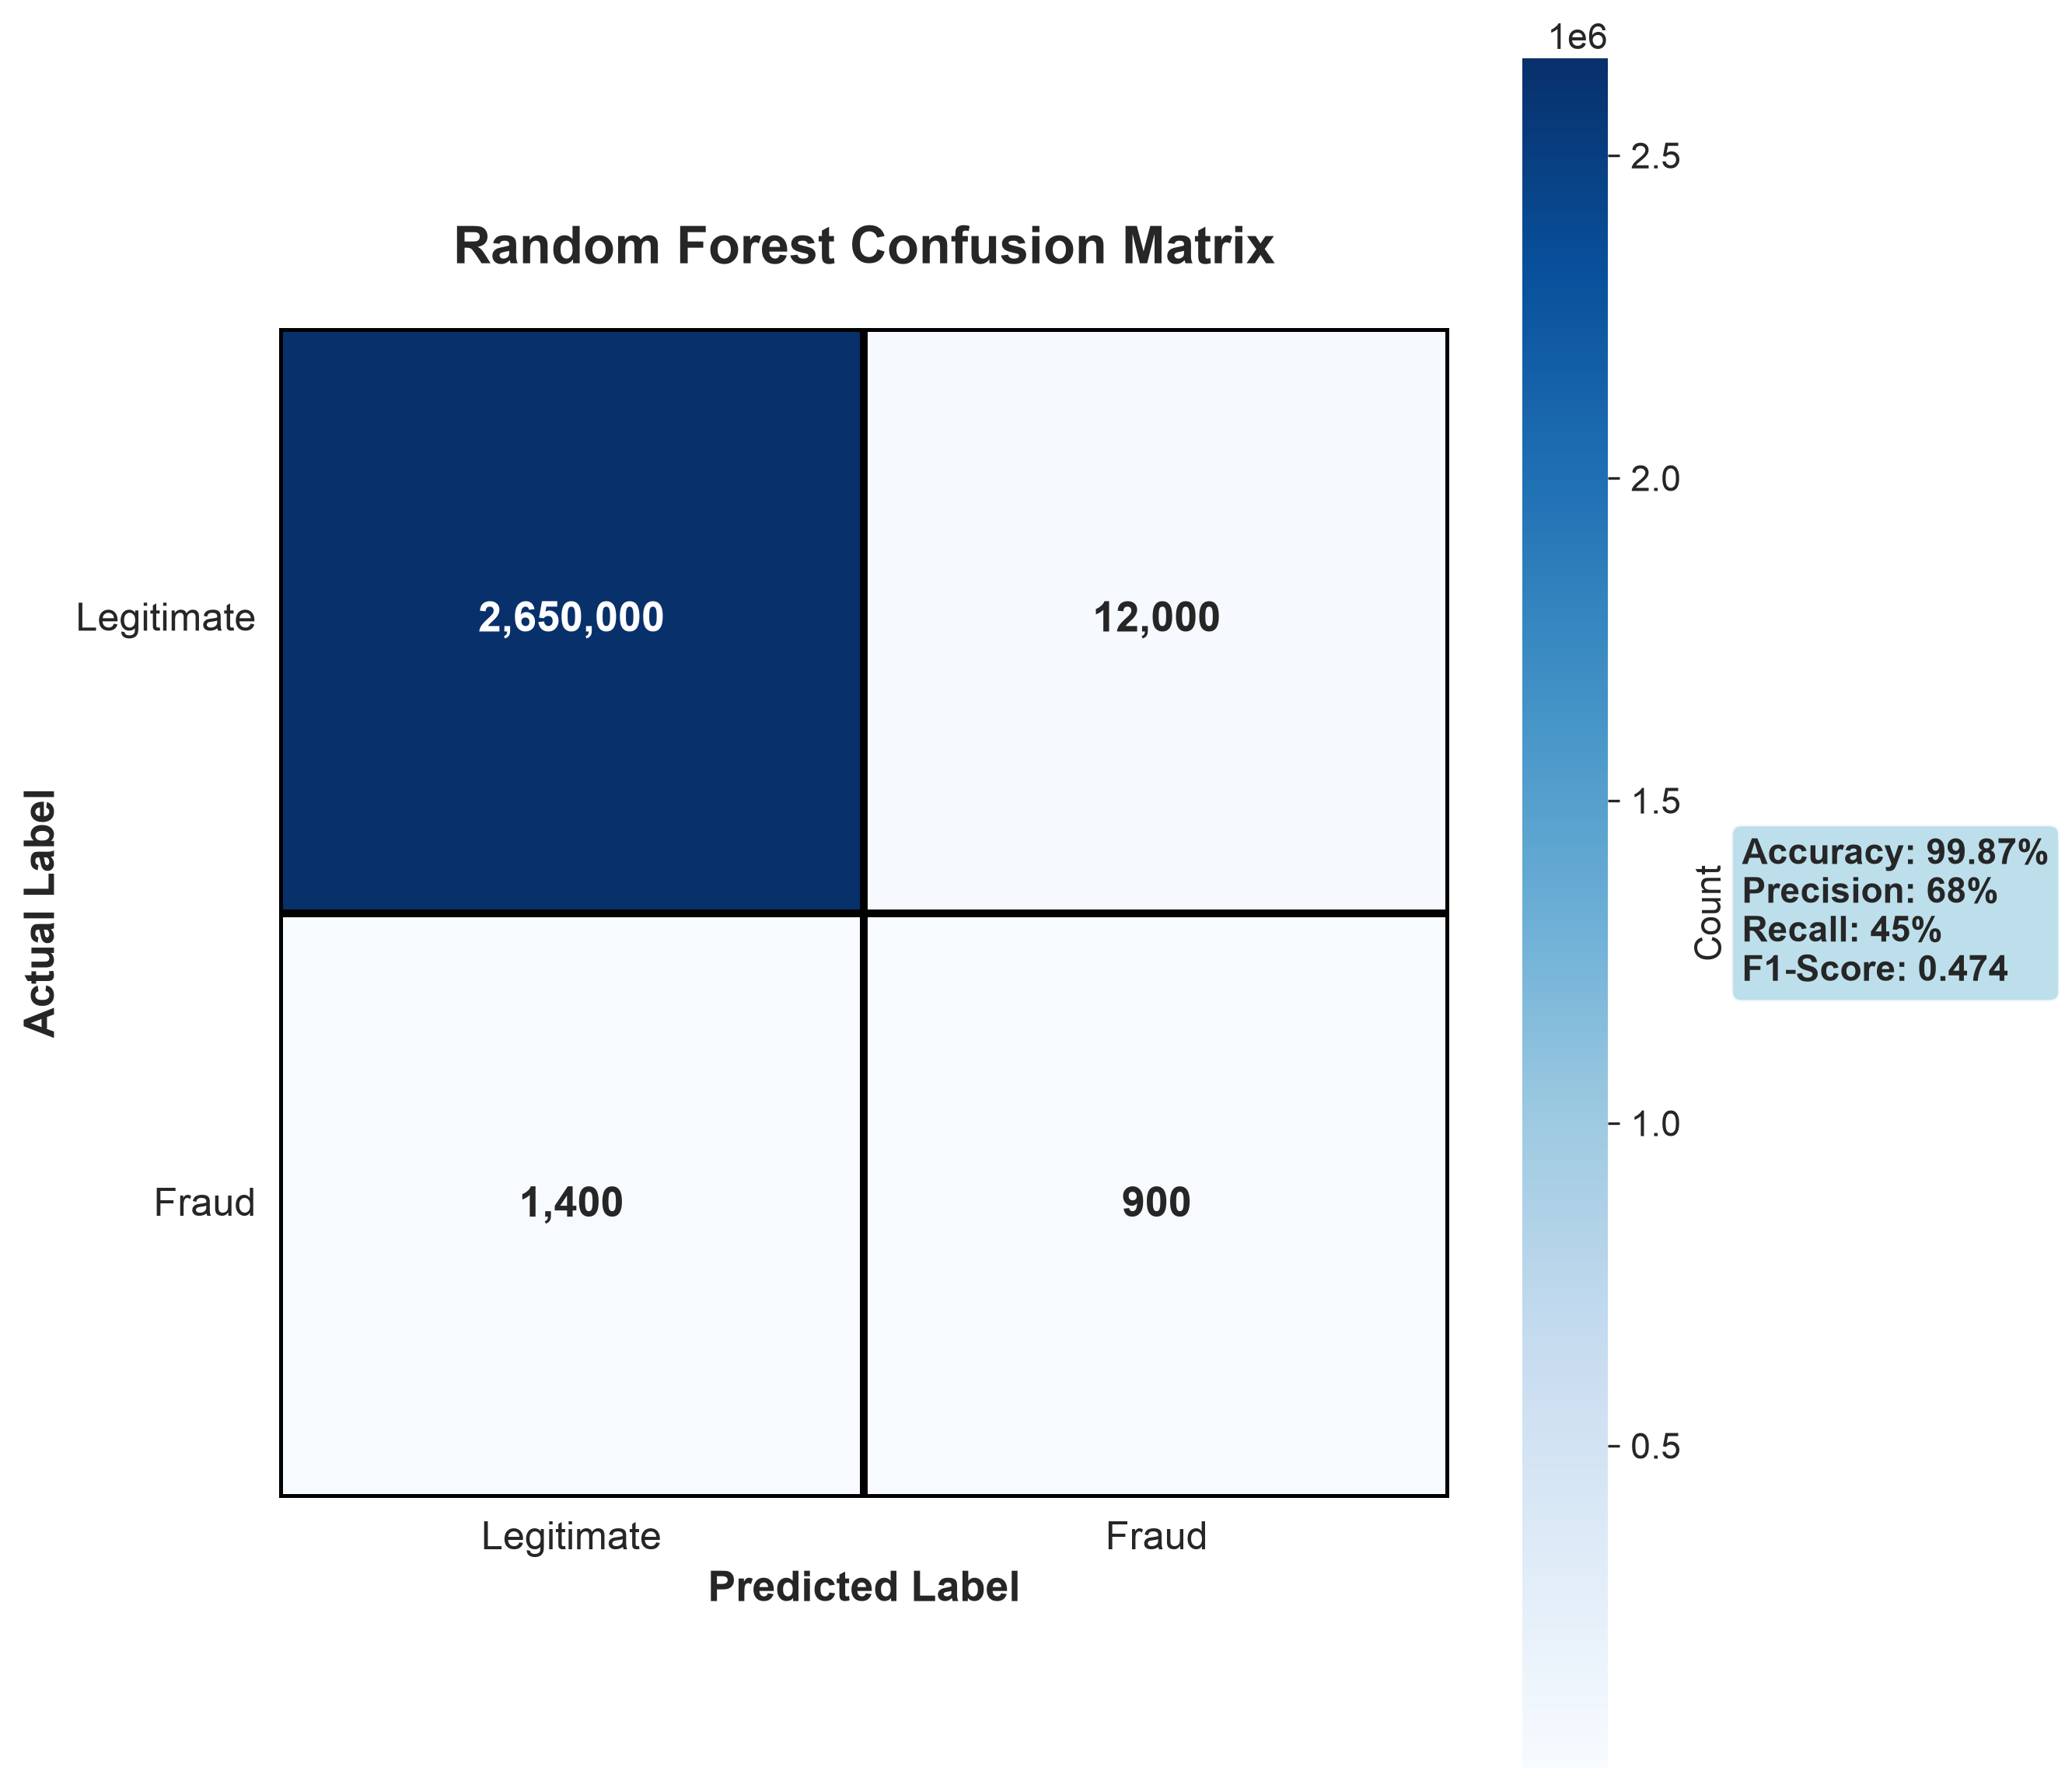

In [1]:
# Random Forest Confusion Matrix
cm = np.array([[2650000, 12000],
               [1400, 900]])

plt.figure(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt=',.0f', cmap='Blues', cbar_kws={'label': 'Count'},
            linewidths=2, linecolor='black', square=True,
            annot_kws={'size': 13, 'weight': 'bold'})

plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label', fontsize=13, fontweight='bold')
plt.title('Random Forest Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks([0.5, 1.5], ['Legitimate', 'Fraud'], fontsize=12)
plt.yticks([0.5, 1.5], ['Legitimate', 'Fraud'], fontsize=12, rotation=0)

# Add metrics text
metrics_text = ('Accuracy: 99.87%\n'
                'Precision: 68%\n'
                'Recall: 45%\n'
                'F1-Score: 0.474')
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
plt.text(1.25, 0.5, metrics_text, fontsize=11, fontweight='bold',
         bbox=props, transform=plt.gca().transAxes, verticalalignment='center')

plt.tight_layout()
plt.savefig('assets/images/rf_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()